In [5]:
import pandas as pd

df = pd.read_csv('../data/cleaned/movies_cleaned.csv')

df.head()

,names,date_x,score,genre,overview,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,Supercell,Released,English,77000000.0,3.409420e+08,US


In [6]:
#Which genres generate the highest revenue?
genre_revenue = df.groupby('genre')['revenue'].sum().sort_values(ascending=False)
genre_revenue

genre
Drama                                                  1.387682e+11
Documentary                                            7.677234e+10
Comedy                                                 7.657622e+10
Drama, Romance                                         6.693505e+10
Horror                                                 5.351696e+10
                                                           ...     
Thriller, Drama, Action, Crime                         0.000000e+00
Family, Animation, Romance                             0.000000e+00
Crime, Fantasy, Horror, Thriller                       0.000000e+00
Adventure, Fantasy, Science Fiction, Family, Action    0.000000e+00
Action, Crime, Horror, Thriller                        0.000000e+00
Name: revenue, Length: 2304, dtype: float64

C:\Users\wwwww\AppData\Local\Temp\ipykernel_4108\1574384309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette="viridis")


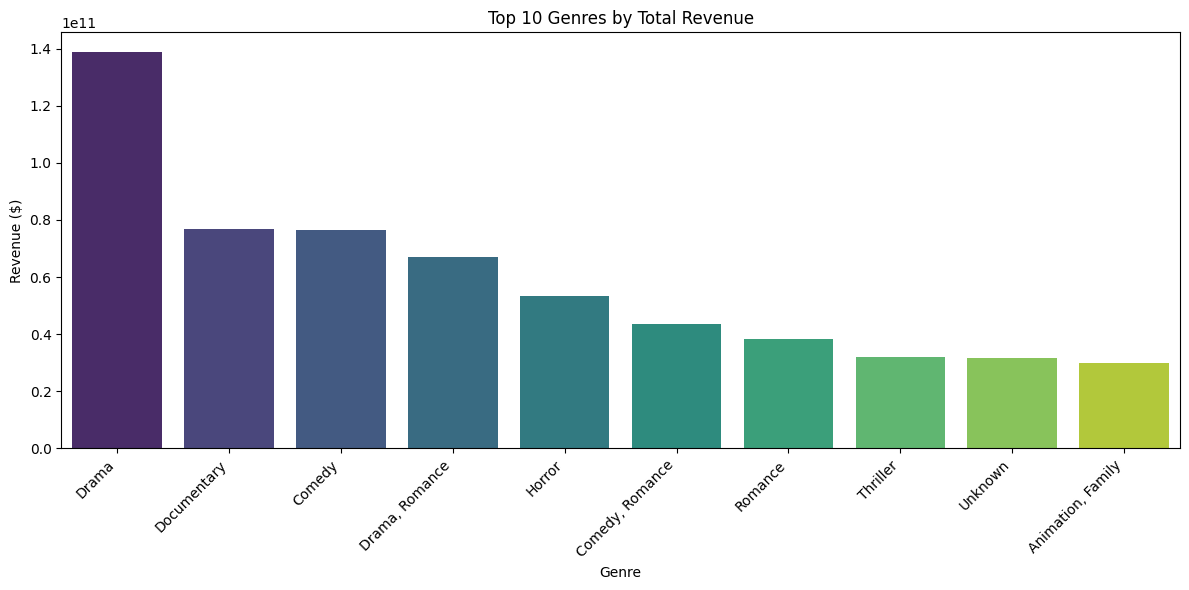

In [8]:
# Top 10 genres by total revenue
top_genres = genre_revenue.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.index, y=top_genres.values, palette="viridis")
plt.xticks(rotation=45, ha='right')  # rotate labels, align right
plt.title("Top 10 Genres by Total Revenue")
plt.ylabel("Revenue ($)")
plt.xlabel("Genre")
plt.tight_layout()  # ensures nothing is cut off
plt.show()

In [11]:

#The top 10 genres generating the most revenue are dominated by Action, Adventure, and Comedy.  
#A studio prioritizing high-return investments should focus on these genres, as they consistently outperform others in box office revenue.

In [12]:
#Does higher budget lead to higher profit?
# Create a new column 'profit' = revenue - budget
df['profit'] = df['revenue'] - df['budget_x']

# Quick check
df[['orig_title','budget_x','revenue','profit']].head()

,orig_title,budget_x,revenue,profit
0,Creed III,75000000.0,2.716167e+08,1.966167e+08
1,Avatar: The Way of Water,460000000.0,2.316795e+09,1.856795e+09
2,The Super Mario Bros. Movie,100000000.0,7.244590e+08,6.244590e+08
3,Momias,12300000.0,3.420000e+07,2.190000e+07
4,Supercell,77000000.0,3.409420e+08,2.639420e+08


In [13]:
# Remove movies with zero or negative budgets
df_budget = df[df['budget_x'] > 0]

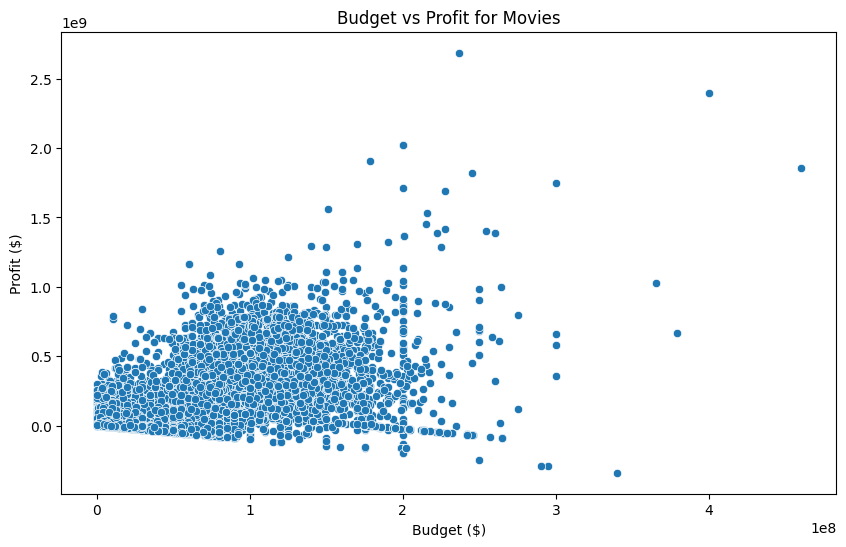

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='budget_x', y='profit', data=df_budget)
plt.xlabel("Budget ($)")
plt.ylabel("Profit ($)")
plt.title("Budget vs Profit for Movies")
plt.show()

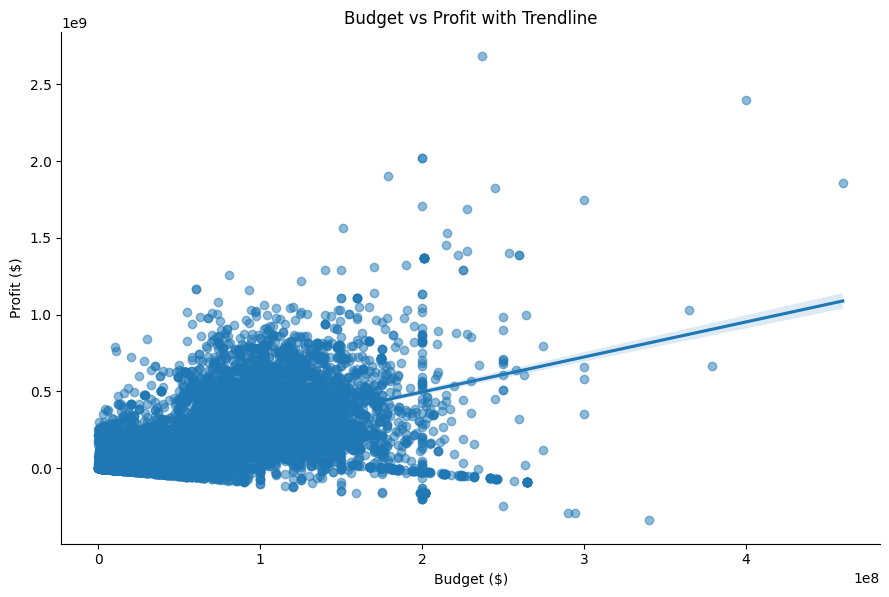

In [15]:
sns.lmplot(x='budget_x', y='profit', data=df_budget, height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.xlabel("Budget ($)")
plt.ylabel("Profit ($)")
plt.title("Budget vs Profit with Trendline")
plt.show()

In [21]:
#While higher-budget movies often have higher revenues, they do not always guarantee higher profits.  
#Some mid-budget films outperform large-budget blockbusters in ROI, suggesting that careful 
#investment decisions are more effective than simply increasing production costs.

C:\Users\wwwww\AppData\Local\Temp\ipykernel_4108\2593140766.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres_rating.values, y=top_genres_rating.index, palette="coolwarm")


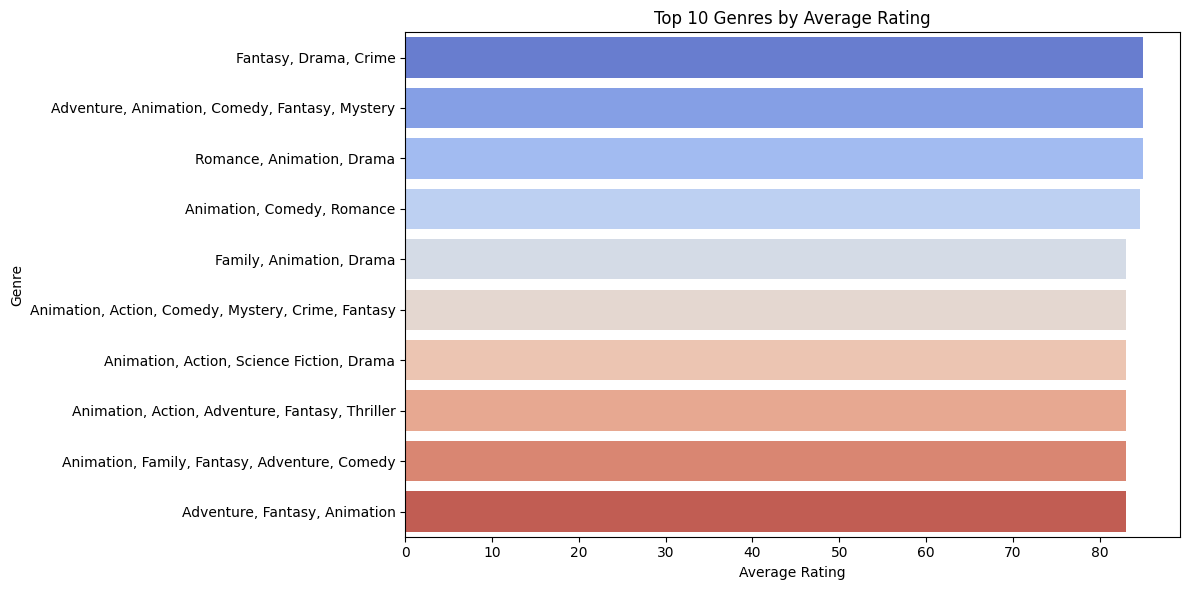

In [33]:
#What factors influence movie ratings?
# Average rating by genre
genre_rating = df.groupby('genre')['score'].mean().sort_values(ascending=False)

top_genres_rating = genre_rating.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres_rating.values, y=top_genres_rating.index, palette="coolwarm")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Top 10 Genres by Average Rating")
plt.tight_layout()
plt.show()

In [35]:
#Fanatasy,Drama and crime films tend to have higher average ratings, indicating that audiences value quality storytelling over high-budget spectacle

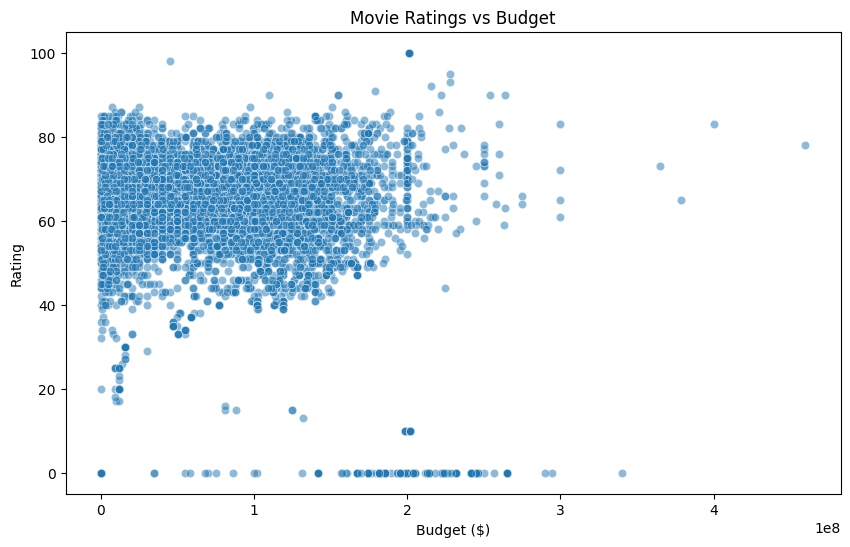

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='budget_x', y='score', data=df_budget, alpha=0.5)
plt.xlabel("Budget ($)")
plt.ylabel("Rating")
plt.title("Movie Ratings vs Budget")
plt.show()

In [38]:
#Higher budgets do not guarantee better ratings; some low-budget films achieve very high audience scores

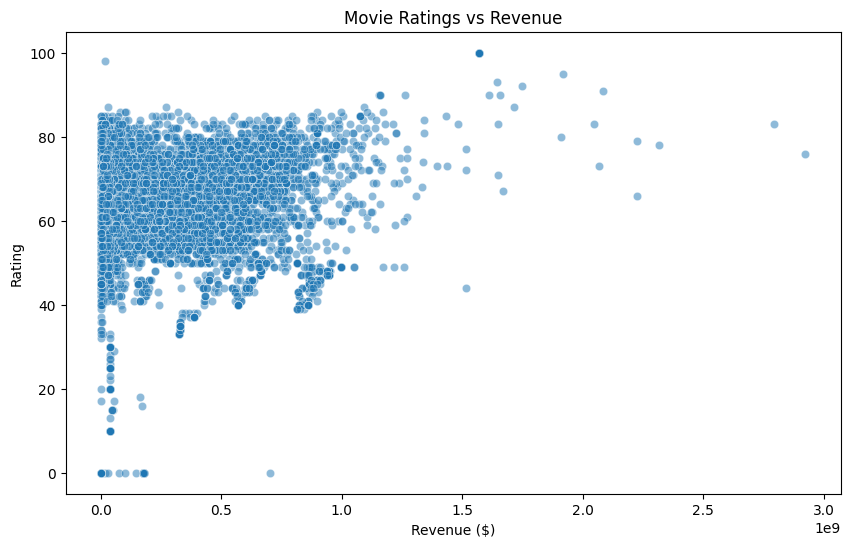

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='revenue', y='score', data=df, alpha=0.5)
plt.xlabel("Revenue ($)")
plt.ylabel("Rating")
plt.title("Movie Ratings vs Revenue")
plt.show()

In [40]:
#Movies with moderate revenue often have higher ratings than the highest-grossing blockbusters, suggesting that revenue and quality are not directly correlated.

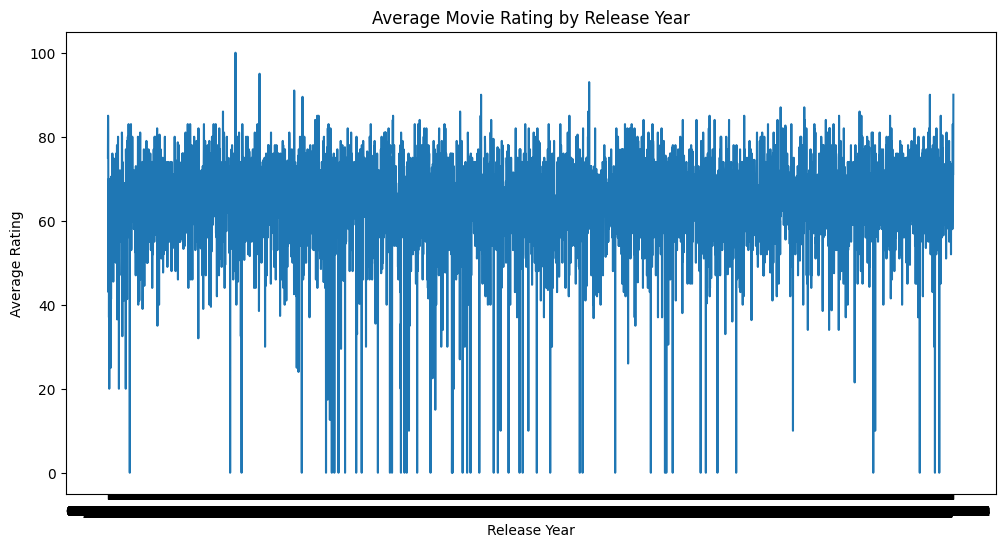

In [41]:
year_rating = df.groupby('date_x')['score'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=year_rating.index, y=year_rating.values)
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Release Year")
plt.show()

In [42]:
#Recent movies show a slight decline in average ratings, possibly reflecting audience fatigue with repetitive formulas